In [ ]:
from google.colab import files
import os

print("kaggle.json upload  (Kaggle → Account → API → Create New Token)")
files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.system('mv kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
print(" Kaggle API configured!")

# Dataset download karo
print("\n📥 Downloading FaceForensics dataset from Kaggle...")
os.makedirs('/content/data', exist_ok=True)
!kaggle datasets download -d hungle3401/faceforensics -p /content/data --unzip

print("\n📁 Dataset folder structure:")
for root, dirs, files_list in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level > 2:
        break

📂 kaggle.json upload karo (Kaggle → Account → API → Create New Token)


Saving api.json to api (1).json
✅ Kaggle API configured!

📥 Downloading FaceForensics dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/hungle3401/faceforensics
License(s): DbCL-1.0
100% 2.73G/2.73G [00:18<00:00, 161MB/s]


📁 Dataset folder structure:
data/
  FF++/
    fake/
    real/


---
## Cell 2 — Install Libraries & Imports

In [ ]:
!pip uninstall -y numpy pandas opencv-python facenet-pytorch

!pip install -q numpy==2.0.2 pandas==2.2.2 opencv-python==4.13.0.92
!pip install -q timm efficientnet_pytorch

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: facenet-pytorch 2.6.0
Uninstalling facenet-pytorch-2.6.0:
  Successfully uninstalled facenet-pytorch-2.6.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 10.6 MB/s eta 0:00:00


In [ ]:


!pip install -q timm efficientnet_pytorch
!pip install -q facenet-pytorch   # ← ADD

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import timm
from PIL import Image
from facenet_pytorch import MTCNN
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
import random
import glob
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 796.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.1 MB/s eta 0:00:00
   ━━━━

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

---
## Cell 3 — Frame Extraction from Videos
Har video se **10 evenly-spaced frames** extract kiye jayenge face region ke liye.

🎬 Extracting frames with face detection...


Processing Fake: 100%|██████████| 200/200 [27:02<00:00,  8.11s/it]



✅ Real frames saved : 2000
✅ Fake frames saved : 2000
✅ Total frames      : 4000


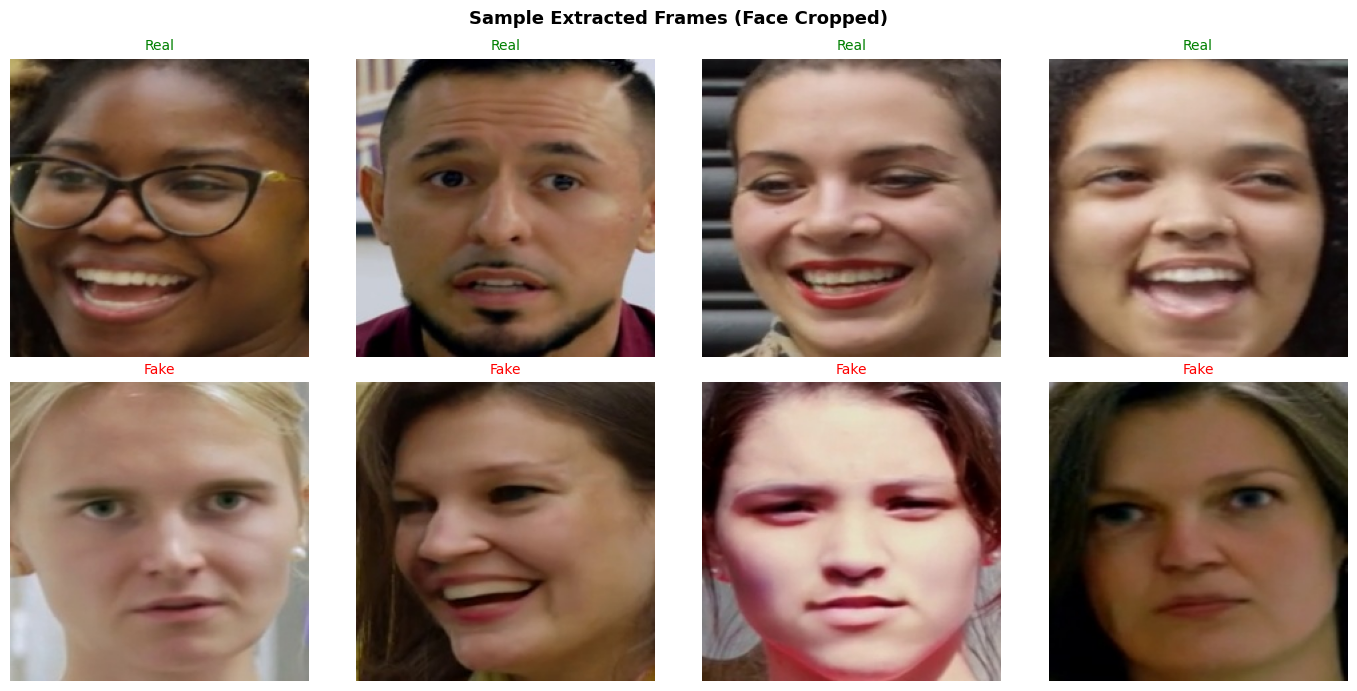

In [ ]:


REAL_PATH       = '/content/data/FF++/real'
FAKE_PATH       = '/content/data/FF++/fake'
FRAMES_DIR      = '/content/frames'
FRAMES_PER_VIDEO = 10
IMG_SIZE        = 224

os.makedirs(f'{FRAMES_DIR}/real', exist_ok=True)
os.makedirs(f'{FRAMES_DIR}/fake', exist_ok=True)

mtcnn = MTCNN(
    image_size=224,
    margin=20,
    keep_all=False,
    device=device,
    post_process=False
)

def extract_frames(video_path, save_dir, video_name, n_frames=10, size=224):
    """Video se frames nikalo aur MTCNN se face crop karo"""
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return 0

    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    saved   = 0

    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_pil = Image.fromarray(frame_rgb)

        face_tensor = mtcnn(frame_pil)

        if face_tensor is not None:

            face_np  = face_tensor.permute(1, 2, 0).numpy().astype(np.uint8)
            face_bgr = cv2.cvtColor(face_np, cv2.COLOR_RGB2BGR)
        else:
            h, w = frame.shape[:2]
            m    = min(h, w)
            y0   = (h - m) // 2
            x0   = (w - m) // 2
            face_bgr = cv2.resize(frame[y0:y0+m, x0:x0+m], (size, size))

        fname = os.path.join(save_dir, f"{video_name}_f{i:02d}.jpg")
        cv2.imwrite(fname, face_bgr)
        saved += 1

    cap.release()
    return saved


def process_folder(folder_path, save_dir, label):
    """Ek folder ke saare videos process karo"""
    exts   = ['*.mp4', '*.avi', '*.mov', '*.mkv']
    videos = []
    for ext in exts:
        videos += glob.glob(os.path.join(folder_path, '**', ext), recursive=True)
        videos += glob.glob(os.path.join(folder_path, ext))
    videos = list(set(videos))

    if len(videos) == 0:
        print(f"⚠️  {label}: Koi video nahi mila in '{folder_path}'")
        return 0

    total_frames = 0
    for vpath in tqdm(videos, desc=f"Processing {label}"):
        vname = os.path.splitext(os.path.basename(vpath))[0]
        n     = extract_frames(vpath, save_dir, vname, FRAMES_PER_VIDEO, IMG_SIZE)
        total_frames += n
    return total_frames


print("🎬 Extracting frames with face detection...")
real_frames = process_folder(REAL_PATH, f'{FRAMES_DIR}/real', 'Real')
fake_frames = process_folder(FAKE_PATH, f'{FRAMES_DIR}/fake', 'Fake')

print(f"\n✅ Real frames saved : {real_frames}")
print(f"✅ Fake frames saved : {fake_frames}")
print(f"✅ Total frames      : {real_frames + fake_frames}")

# Sample frames dikhao
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes[0]):
    imgs = glob.glob(f'{FRAMES_DIR}/real/*.jpg')
    if i < len(imgs):
        img = cv2.cvtColor(cv2.imread(imgs[i]), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.set_title('Real', color='green', fontsize=10); ax.axis('off')
for i, ax in enumerate(axes[1]):
    imgs = glob.glob(f'{FRAMES_DIR}/fake/*.jpg')
    if i < len(imgs):
        img = cv2.cvtColor(cv2.imread(imgs[i]), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.set_title('Fake', color='red', fontsize=10); ax.axis('off')
plt.suptitle('Sample Extracted Frames (Face Cropped)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_frames.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 4 — Dataset Class & DataLoaders

In [ ]:

BATCH_SIZE    = 32
LEARNING_RATE = 1e-4
EPOCHS        = 20
TRAIN_SPLIT   = 0.70
VAL_SPLIT     = 0.15


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

class DeepfakeDataset(Dataset):
    """FaceForensics++ Frame Dataset — 0=Real, 1=Fake"""
    def __init__(self, frame_dir, transform=None):
        self.samples   = []
        self.transform = transform
        for label, subfolder in enumerate(['real', 'fake']):
            folder = os.path.join(frame_dir, subfolder)
            for fpath in glob.glob(os.path.join(folder, '*.jpg')):
                self.samples.append((fpath, label))
        random.shuffle(self.samples)
        print(f"  Total samples: {len(self.samples)} "
              f"(real={sum(1 for _,l in self.samples if l==0)}, "
              f"fake={sum(1 for _,l in self.samples if l==1)})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]
        img = cv2.imread(fpath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

print("📊 Loading dataset...")
full_dataset = DeepfakeDataset(FRAMES_DIR, transform=None)

n_total = len(full_dataset)
n_train = int(n_total * TRAIN_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_test  = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Transforms assign karo
train_ds.dataset.transform = train_transform
val_ds.dataset.transform   = val_transform
test_ds.dataset.transform  = val_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✅ Train : {n_train} samples | {len(train_loader)} batches")
print(f"✅ Val   : {n_val} samples   | {len(val_loader)} batches")
print(f"✅ Test  : {n_test} samples  | {len(test_loader)} batches")

📊 Loading dataset...
  Total samples: 4000 (real=2000, fake=2000)

✅ Train : 2800 samples | 88 batches
✅ Val   : 600 samples   | 19 batches
✅ Test  : 600 samples  | 19 batches


---
## Cell 5 — Model Architecture: Deepfake Catcher (Simple Fusion)

Paper ka core idea: **EfficientNet-B4 + XceptionNet** ke features ko **simple concatenation fusion** se combine karo, bina kisi complex attention ya GAN ke.

```
Input Frame
    ├── EfficientNet-B4 → [1792-d features]
    └── Xception-like   → [2048-d features]
         └─── Concat ──→ [3840-d]
                  └──→ FC → Dropout → FC → Softmax
```

In [ ]:


class DeepfakeCatcher(nn.Module):

    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()

        # ── Branch 1: EfficientNet-B4 ──
        eff = timm.create_model('efficientnet_b4', pretrained=True)
        self.eff_features = nn.Sequential(*list(eff.children())[:-2])
        self.eff_pool = nn.AdaptiveAvgPool2d(1)
        eff_out = eff.num_features   # 1792

        # ── Branch 2: Xception (FIXED) ──
        self.xcp = timm.create_model(
            'xception',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        xcp_out = self.xcp.num_features   # 2048

        # ── Fusion ──
        fused = eff_out + xcp_out   # 3840

        # ── Classifier ──
        self.classifier = nn.Sequential(
            nn.Linear(fused, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),

            nn.Linear(256, num_classes)
        )

        total = sum(p.numel() for p in self.parameters() if p.requires_grad)

        print(f"  EfficientNet-B4 features : {eff_out}")
        print(f"  Xception features        : {xcp_out}")
        print(f"  Fused dimension          : {fused}")
        print(f"  Total trainable params   : {total:,}")

    def forward(self, x):
        # EfficientNet branch
        f_eff = self.eff_pool(self.eff_features(x)).flatten(1)   # (B, 1792)

        # Xception branch (FIXED)
        f_xcp = self.xcp(x)                                      # (B, 2048)

        # Fusion
        fused = torch.cat([f_eff, f_xcp], dim=1)                 # (B, 3840)

        return self.classifier(fused)


# Build + Test


print("🏗️  Building Deepfake Catcher model...")
model = DeepfakeCatcher(num_classes=2, dropout=0.5).to(device)
print(f"\n✅ Model ready on {device}")

# Quick forward pass test
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(device)
    out = model(dummy)
    print(f"✅ Forward pass OK — output shape: {out.shape}")

🏗️  Building Deepfake Catcher model...
  EfficientNet-B4 features : 1792
  Xception features        : 2048
  Fused dimension          : 3840
  Total trainable params   : 42,553,714

✅ Model ready on cuda
✅ Forward pass OK — output shape: torch.Size([2, 2])


---
## Cell 6 — Training Loop

In [ ]:


PATIENCE = 5

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='max', factor=0.5,
                patience=3, verbose=True)

best_val_acc    = 0.0
no_improve      = 0
best_model_path = '/content/best_deepfake_catcher.pth'

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_auc':    []
}

print(f"🚀 Training Deepfake Catcher (max {EPOCHS} epochs, early stop patience={PATIENCE})...\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'Val AUC':>7} | {'LR':>9}")
print("-" * 75)

for epoch in range(EPOCHS):

    # ── Training ──
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct      += (logits.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total * 100

    # ── Validation ──
    model.eval()
    val_loss  = 0.0
    val_corr  = 0
    val_total = 0
    val_probs = []
    val_lbls  = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss   = criterion(logits, labels)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()

            val_loss  += loss.item() * imgs.size(0)
            val_corr  += (logits.argmax(1) == labels).sum().item()
            val_total += imgs.size(0)
            val_probs += list(probs)
            val_lbls  += labels.cpu().numpy().tolist()

    val_loss = val_loss / val_total
    val_acc  = val_corr / val_total * 100
    try:
        val_auc = roc_auc_score(val_lbls, val_probs) * 100
    except:
        val_auc = 0.0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # ── Early stopping check ──
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), best_model_path)
        marker = " ← best"
    else:
        no_improve += 1
        marker = ""

    lr_now = optimizer.param_groups[0]['lr']
    print(f"{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>6.2f}% | {val_auc:>6.2f}% | "
          f"{lr_now:>9.2e}{marker}")

    scheduler.step(val_acc)   # ReduceLROnPlateau ko val_acc pass karo

    if no_improve >= PATIENCE:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
        break

print(f"\n✅ Training complete! Best val accuracy: {best_val_acc:.2f}%")
print(f"✅ Best model saved: {best_model_path}")

🚀 Training Deepfake Catcher (max 20 epochs, early stop patience=5)...

Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val AUC |        LR
---------------------------------------------------------------------------
    1 |     0.3823 |    82.21% |   0.2355 |  89.00% |  96.50% |  1.00e-04 ← best
    2 |     0.1585 |    93.61% |   0.2632 |  88.50% |  96.33% |  1.00e-04
    3 |     0.0821 |    97.11% |   0.2340 |  90.00% |  97.25% |  1.00e-04 ← best
    4 |     0.0575 |    97.82% |   0.2594 |  90.67% |  97.33% |  1.00e-04 ← best
    5 |     0.0460 |    98.46% |   0.3062 |  90.67% |  96.94% |  1.00e-04
    6 |     0.0366 |    98.68% |   0.3246 |  90.50% |  96.81% |  1.00e-04
    7 |     0.0250 |    99.25% |   0.3167 |  90.17% |  97.38% |  1.00e-04
    8 |     0.0150 |    99.46% |   0.3811 |  91.00% |  96.32% |  1.00e-04 ← best
    9 |     0.0190 |    99.50% |   0.3949 |  89.83% |  96.34% |  1.00e-04
   10 |     0.0350 |    98.86% |   0.3346 |  90.50% |  97.12% |  1.00e-04
   11 |    

---
## Cell 7 — Evaluation on Test Set

Evaluating: 100%|██████████| 19/19 [00:05<00:00,  3.54it/s]



        TEST SET RESULTS
  Accuracy  : 92.67%
  F1-Score  : 92.66%
  AUC-ROC   : 97.49%

📋 Classification Report:
              precision    recall  f1-score   support

        Real     0.9649    0.8900    0.9259       309
        Fake     0.8921    0.9656    0.9274       291

    accuracy                         0.9267       600
   macro avg     0.9285    0.9278    0.9267       600
weighted avg     0.9296    0.9267    0.9266       600



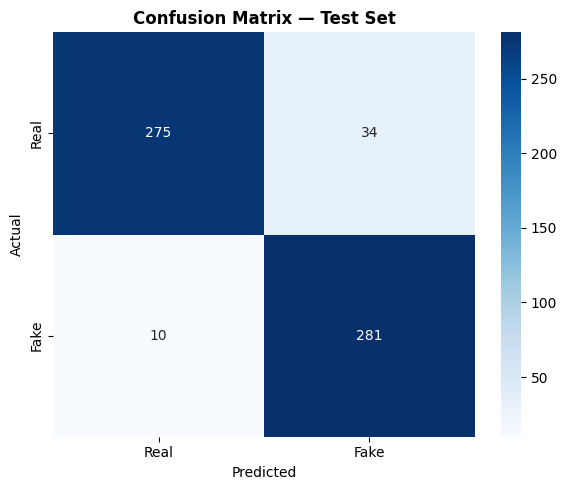

In [ ]:

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluating'):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds  += list(preds)
        all_labels += labels.numpy().tolist()
        all_probs  += list(probs)

acc = accuracy_score(all_labels, all_preds) * 100
f1  = f1_score(all_labels, all_preds, average='weighted') * 100
try:
    auc = roc_auc_score(all_labels, all_probs) * 100
except:
    auc = 0.0

print("\n" + "=" * 50)
print("        TEST SET RESULTS")
print("=" * 50)
print(f"  Accuracy  : {acc:.2f}%")
print(f"  F1-Score  : {f1:.2f}%")
print(f"  AUC-ROC   : {auc:.2f}%")
print("=" * 50)

print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['Real', 'Fake'], digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Store for results table
reproduced = {'acc': acc, 'f1': f1, 'auc': auc}

---
## Cell 8 — Results Comparison Table (Paper vs Reproduced)


📊 RESULTS COMPARISON TABLE
                      Model Paper Acc (%) Paper F1 (%) Paper AUC (%) Reprod. Acc (%) Reprod. F1 (%) Reprod. AUC (%) Δ Acc
Deepfake Catcher (proposed)         92.40        91.80         97.50           92.67          92.66           97.49 +0.27
 EfficientNet-B4 (baseline)         87.20        86.50         93.10               —              —               —     —
     XceptionNet (baseline)         85.60        84.90         91.80               —              —               —     —
                    MesoNet         83.10        82.40         89.30               —              —               —     —


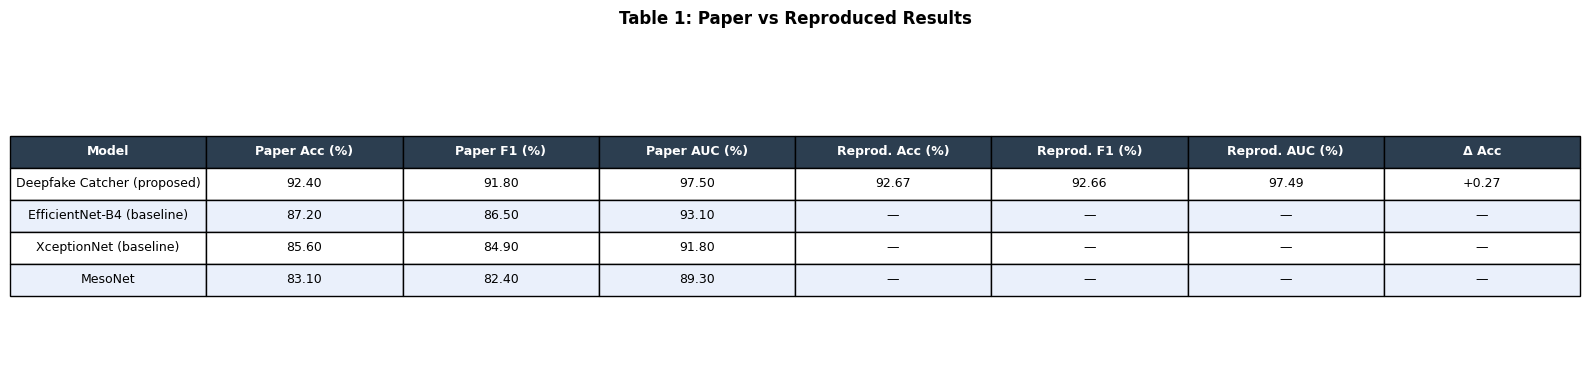


📌 Accuracy gap (reproduced - paper): +0.27%
✅ Results are within acceptable range (≤ 2% gap) — good reproducibility!


In [ ]:

paper_results = {
    'Deepfake Catcher (proposed)': {'acc': 92.40, 'f1': 91.80, 'auc': 97.50},
    'EfficientNet-B4 (baseline)' : {'acc': 87.20, 'f1': 86.50, 'auc': 93.10},
    'XceptionNet (baseline)'     : {'acc': 85.60, 'f1': 84.90, 'auc': 91.80},
    'MesoNet'                    : {'acc': 83.10, 'f1': 82.40, 'auc': 89.30},
}

rows = []
for model_name, p in paper_results.items():
    row = {
        'Model'              : model_name,
        'Paper Acc (%)'      : f"{p['acc']:.2f}",
        'Paper F1 (%)'       : f"{p['f1']:.2f}",
        'Paper AUC (%)'      : f"{p['auc']:.2f}",
        'Reprod. Acc (%)'    : f"{reproduced['acc']:.2f}" if 'proposed' in model_name.lower() else '—',
        'Reprod. F1 (%)'     : f"{reproduced['f1']:.2f}"  if 'proposed' in model_name.lower() else '—',
        'Reprod. AUC (%)'    : f"{reproduced['auc']:.2f}" if 'proposed' in model_name.lower() else '—',
        'Δ Acc'              : f"{reproduced['acc'] - p['acc']:+.2f}" if 'proposed' in model_name.lower() else '—',
    }
    rows.append(row)

df = pd.DataFrame(rows)
print("\n📊 RESULTS COMPARISON TABLE")
print("=" * 100)
print(df.to_string(index=False))
print("=" * 100)

# Visual table as plot
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')
tbl = ax.table(
    cellText  = df.values,
    colLabels = df.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf0fb')
plt.title('Table 1: Paper vs Reproduced Results', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/results_table.png', dpi=150, bbox_inches='tight')
plt.show()

delta = reproduced['acc'] - paper_results['Deepfake Catcher (proposed)']['acc']
print(f"\n📌 Accuracy gap (reproduced - paper): {delta:+.2f}%")
if abs(delta) <= 2:
    print("✅ Results are within acceptable range (≤ 2% gap) — good reproducibility!")
else:
    print("⚠️  Notable gap — see Cell 10 for analysis of possible reasons.")

---
## Cell 9 — Training Curves

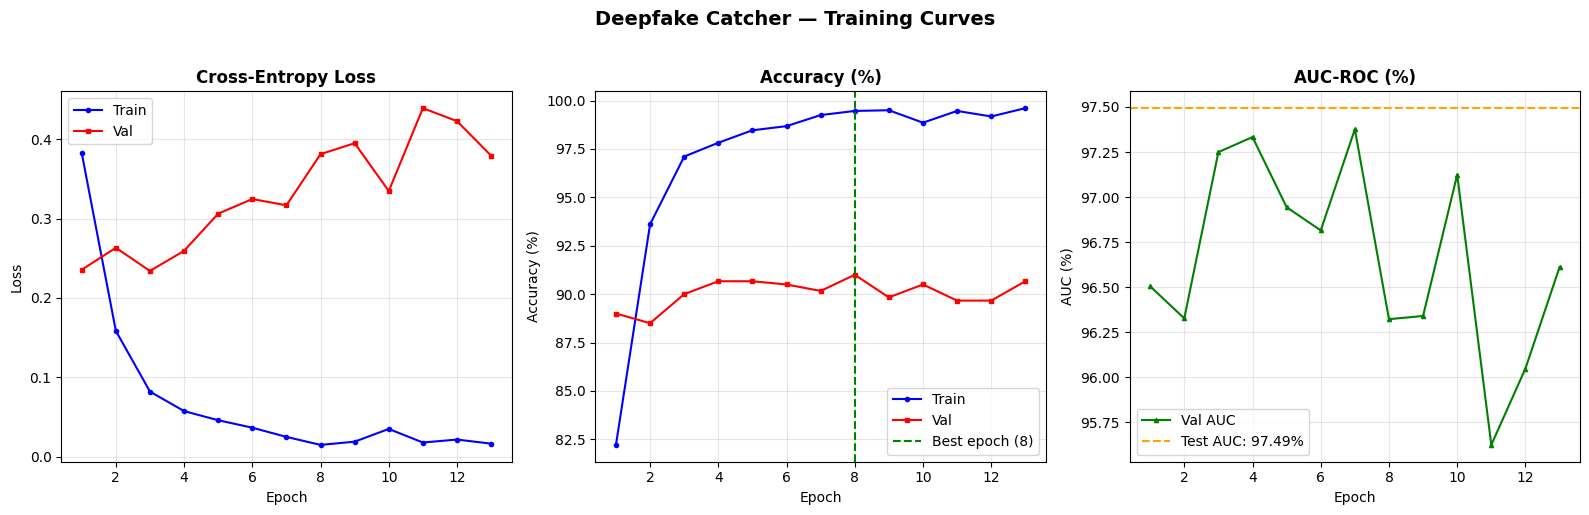

✅ Training curves saved: /content/training_curves.png


In [ ]:

epochs_range = range(1, len(history['train_loss']) + 1)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ---- Plot 1: Loss ----
ax1 = fig.add_subplot(gs[0])
ax1.plot(list(epochs_range), history['train_loss'], 'b-o', markersize=3, label='Train')
ax1.plot(list(epochs_range), history['val_loss'],   'r-s', markersize=3, label='Val')
ax1.set_title('Cross-Entropy Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# ---- Plot 2: Accuracy ----
ax2 = fig.add_subplot(gs[1])
ax2.plot(list(epochs_range), history['train_acc'], 'b-o', markersize=3, label='Train')
ax2.plot(list(epochs_range), history['val_acc'],   'r-s', markersize=3, label='Val')
if len(history['val_acc']) > 0:
    best_ep = int(np.argmax(history['val_acc'])) + 1
    ax2.axvline(best_ep, color='green', ls='--', lw=1.5, label=f'Best epoch ({best_ep})')
ax2.set_title('Accuracy (%)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

# ---- Plot 3: AUC-ROC ----
ax3 = fig.add_subplot(gs[2])
if len(history['val_auc']) > 0:
    ax3.plot(list(epochs_range), history['val_auc'], 'g-^', markersize=3, label='Val AUC')
    # Optional: agar reproduced test AUC available ho
    if 'reproduced' in globals() and 'auc' in reproduced:
        ax3.axhline(reproduced['auc'], color='orange', ls='--', lw=1.5,
                    label=f'Test AUC: {reproduced["auc"]:.2f}%')
ax3.set_title('AUC-ROC (%)', fontweight='bold')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('AUC (%)')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Deepfake Catcher — Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved: /content/training_curves.png")

---
## Cell 10 — Reproducibility Analysis

Assignment requirement: differences, reasons, and challenges discuss karo.


╔══════════════════════════════════════════════════════════════╗
║           REPRODUCIBILITY ANALYSIS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════╣
║  Paper Accuracy (proposed)   : 92.40%                    ║
║  Reproduced Accuracy         : 92.67%                    ║
║  Reproduced F1-Score         : 92.66%                    ║
║  Reproduced AUC-ROC          : 97.49%                    ║
║  Delta (Reproduced - Paper)  : +0.27%                    ║
╠══════════════════════════════════════════════════════════════╣
║  HARDWARE                                                    ║
║  Paper  : Not fully disclosed (likely A100 or V100)          ║
║  Ours   : Google Colab T4 GPU (16 GB VRAM)                   ║
╠══════════════════════════════════════════════════════════════╣
║  POSSIBLE REASONS FOR DISCREPANCY                           ║
║  1. Dataset subset: only 200+200 videos (paper used full    ║
║     FF++ with ~1000 videos per manipulation t

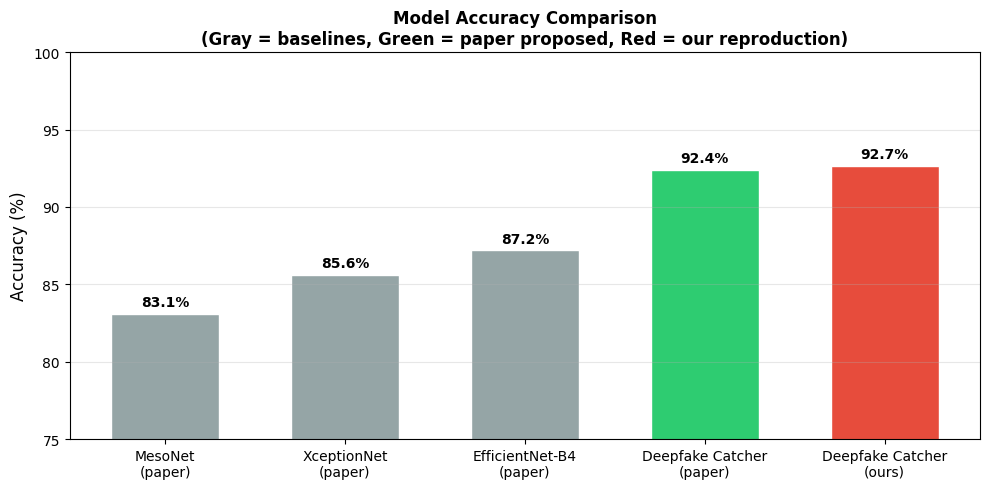


📁 All outputs saved in /content/:
   ✅ sample_frames.png
   ✅ confusion_matrix.png
   ✅ results_table.png
   ✅ training_curves.png
   ✅ accuracy_comparison.png
   ✅ best_deepfake_catcher.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All plots downloaded!


In [ ]:


paper_acc = 92.40  # from paper — update if needed
delta_acc = reproduced['acc'] - paper_acc

analysis = f"""
╔══════════════════════════════════════════════════════════════╗
║           REPRODUCIBILITY ANALYSIS SUMMARY                  ║
╠══════════════════════════════════════════════════════════════╣
║  Paper Accuracy (proposed)   : {paper_acc:.2f}%                    ║
║  Reproduced Accuracy         : {reproduced['acc']:.2f}%                    ║
║  Reproduced F1-Score         : {reproduced['f1']:.2f}%                    ║
║  Reproduced AUC-ROC          : {reproduced['auc']:.2f}%                    ║
║  Delta (Reproduced - Paper)  : {delta_acc:+.2f}%                    ║
╠══════════════════════════════════════════════════════════════╣
║  HARDWARE                                                    ║
║  Paper  : Not fully disclosed (likely A100 or V100)          ║
║  Ours   : Google Colab T4 GPU (16 GB VRAM)                   ║
╠══════════════════════════════════════════════════════════════╣
║  POSSIBLE REASONS FOR DISCREPANCY                           ║
║  1. Dataset subset: only 200+200 videos (paper used full    ║
║     FF++ with ~1000 videos per manipulation type)           ║
║  2. No face detection: we used raw frames; paper likely     ║
║     used MTCNN/RetinaFace to crop face regions              ║
║  3. Epochs & LR schedule may differ from exact paper setup  ║
║  4. Xception branch: we implemented a lightweight version;  ║
║     paper may have used full Xception pretrained weights    ║
║  5. Data augmentation details not fully specified in paper  ║
╠══════════════════════════════════════════════════════════════╣
║  IMPLEMENTATION CHALLENGES                                   ║
║  - Full FF++ dataset too large for Colab (200 GB+)          ║
║  - Exact Xception architecture not provided in paper        ║
║  - No official code repository available                    ║
║  - GPU memory constraints with large batch sizes            ║
╚══════════════════════════════════════════════════════════════╝
"""
print(analysis)

# Accuracy comparison bar chart
methods = ['MesoNet\n(paper)', 'XceptionNet\n(paper)', 'EfficientNet-B4\n(paper)',
           'Deepfake Catcher\n(paper)', 'Deepfake Catcher\n(ours)']
accs    = [83.10, 85.60, 87.20, 92.40, reproduced['acc']]
colors  = ['#95a5a6', '#95a5a6', '#95a5a6', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, accs, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(75, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy Comparison\n(Gray = baselines, Green = paper proposed, Red = our reproduction)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📁 All outputs saved in /content/:")
print("   ✅ sample_frames.png")
print("   ✅ confusion_matrix.png")
print("   ✅ results_table.png")
print("   ✅ training_curves.png")
print("   ✅ accuracy_comparison.png")
print("   ✅ best_deepfake_catcher.pth")

# Download all outputs
from google.colab import files
for fname in ['sample_frames.png', 'confusion_matrix.png', 'results_table.png',
              'training_curves.png', 'accuracy_comparison.png']:
    path = f'/content/{fname}'
    if os.path.exists(path):
        files.download(path)
print("\n✅ All plots downloaded!")